<font size="+4">`Signal and Audio Processing`</font>

<font size="+3">`Seminar 07: Automatic Speech Recognition`</font>

<font size="+2">`Maks Nakhodnov & Dmitry Kropotov`</font>

<font size="+2">`Bremen, 2026`</font>

Что вы узнаете из этого ноутбука:

* Постановка задачи распознавания речи. Метрики. Датасеты. Бенчмарки.
* Encoder-only модели. Гранулярность входных и выходных признаков.
* Soft alignment. CTC. CTC декодинг. Акустические модели vs Языковые модели в декодинге.

In [1]:
import io
import os

os.environ['TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL'] = '1'

from urllib.request import urlopen

import regex

import numpy as np

import torch
import torchaudio
import torchmetrics

import soundfile

import matplotlib.pyplot as plt

from IPython.display import Audio

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# `1. Введение, Признаки и Проблема выравнивания`

## `1.1. Постановка задачи ASR и Входные данные`

**Automatic Speech Recognition (ASR)** или **Speech-to-Text (STT)** — задача преобразования аудиозаписи в последовательность текстовых токенов. В отличие от задач компьютерного зрения или NLP, где входные данные обычно дискретны (пиксели, слова), вход ASR — это непрерывный и **очень длинный временной ряд**. С математической точки зрения, задача распознавания речи — это задача *sequence-to-sequence*.

![](https://images.netcomlearning.com/cms/images/real-world-applications-of-automatic-speech-recognition.jpg)

Пусть у нас есть аудиозапись. В сыром виде это одномерный массив амплитуд звуковой волны $S = (\mathbf{s}_1, \mathbf{s}_2, \dots, \mathbf{s}_T), \quad \mathbf{s}_t \in \mathbb{R}$. Однако подавать сырой звук напрямую в нейросеть — неэффективно. Стандартное решение — извлечение акустических признаков. Тогда задачу можно сформулировать как:

Пусть $X$ — входная последовательность акустических признаков длины $M$, полученная из последовательности $S$:
$$S \longrightarrow X = (\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_M), \quad \mathbf{x}_t \in \mathbb{R}^D$$

Задача ASR — найти такую последовательность текстовых токенов $Y$ длины $N$:
$$Y = (y_1, y_2, \dots, y_N), \quad y_n \in V$$
где $V$ — словарь токенов (буквы, сабворды или слова), которая максимизирует условную вероятность:
$$Y^* = \arg\max_{Y} P(Y | X)$$

В предельном случае, для raw waveform: $X = S, D = 1, M = T$.

*Сложность задачи ASR* кроется в том числе и в физике данных: фоновые шумы, наложения голосов (Cocktail party problem), региональные акценты и вариативность в скорости речи делают отображение $S \to Y$ нетривиальным.

На прошлых занятиях мы обсудили различные способы выделения признаков из звука. В качестве стандарта, индустрия сошлась к использованию спектральных признаков — **Log-Mel Spectrogram**.

Ключевой вопрос перехода в признаковое пространство — это баланс между темпоральным сжатием и размерностью признакового пространства. Log-Mel Spectrogram:
1. За счёт квазистационарности реального звука можно применять Кратковременное преобразование Фурье, которое вычисляет спектр сигнала в окне, тем самым **уменьшая временное разрешение**.
2. Для имитации восприятия человеческим ухом спектрограмма переводится в мел-шкалу. Это убирает избыточность и **сжимает информацию в пространстве признаков**.

![](https://www.researchgate.net/profile/Ascension-Gallardo-Antolin/publication/351844480/figure/fig1/AS:1032783619174405@1623246211664/Block-diagram-of-the-log-mel-spectrogram-computation-process.png)

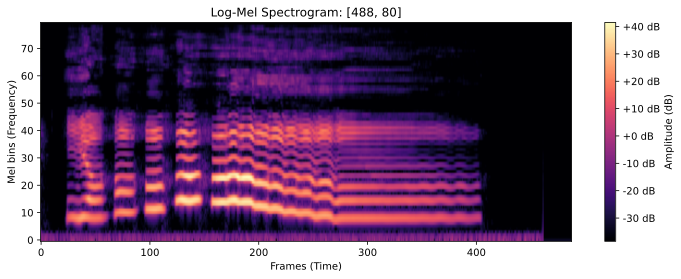

In [2]:
waveform, sample_rate = soundfile.read('./../../Tasks/Task 01/data/singing.wav')
waveform = torch.tensor(waveform, dtype=torch.float32)

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=1200,           # 25 мс * 48 kHz = 1200
    win_length=1200,      # По умолчанию равен n_fft
    hop_length=480,      # Шаг окна (сдвиг). 10 мс * 48 kHz = 480
    n_mels=80,           # Количество Mel-фильтров (бин)
    power=2.0            # 2.0 означает спектрограмму мощности (power spectrogram)
)
db_transform = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)

mel_spectrogram = mel_transform(waveform)
log_mel_spectrogram = db_transform(mel_spectrogram)

fig, ax = plt.subplots(figsize=(10, 4))

image = ax.imshow(log_mel_spectrogram.numpy(), origin='lower', aspect='auto', cmap='magma')
cbar = fig.colorbar(image, ax=ax, format="%+2.0f dB")
cbar.set_label("Amplitude (dB)")

ax.set_title(f"Log-Mel Spectrogram: {list(log_mel_spectrogram.T.shape)}")
ax.set_ylabel("Mel bins (Frequency)")
ax.set_xlabel("Frames (Time)")

plt.tight_layout()
plt.show()

1. Стандартное окно (Window size) — **$25$ миллисекунд**. В пределах $25$ мс речевой тракт человека физически не успевает сильно измениться, поэтому сигнал можно считать квазистационарным.
2. Шаг сдвига окна (Stride/Hop size) составляет **$10$ миллисекунд**. При шаге в $10$ мс, **1 секунда аудио превращается ровно в $100$ фреймов** ($M = 100$).
3. Размерность признакового пространства определяется числом Mel фильтров (Num Mels) и обычно равна $D = 80$.

Если человек говорит фразу длиной $5$ секунд, матрица $X$ будет иметь размер $500 \times 80$. При этом исходное аудио с частотой дискретизации $16$ kHz содержит в $2$ раза больше отсчётов.  

Конечно же, для увеличения размера выборки можно использовать естественные аугментации спектрограмм:

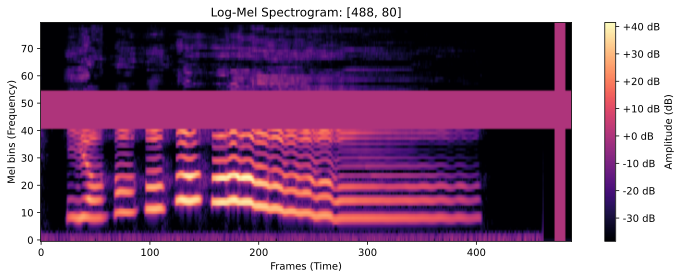

In [3]:
time_masking = torchaudio.transforms.TimeMasking(time_mask_param=20)
freq_masking = torchaudio.transforms.FrequencyMasking(freq_mask_param=15)

fig, ax = plt.subplots(figsize=(10, 4))

image = ax.imshow(time_masking(freq_masking(log_mel_spectrogram)).numpy(), origin='lower', aspect='auto', cmap='magma')
cbar = fig.colorbar(image, ax=ax, format="%+2.0f dB")
cbar.set_label("Amplitude (dB)")

ax.set_title(f"Log-Mel Spectrogram: {list(log_mel_spectrogram.T.shape)}")
ax.set_ylabel("Mel bins (Frequency)")
ax.set_xlabel("Frames (Time)")

plt.tight_layout()
plt.show()

## `1.2. Проблема выравнивания`

Пусть у нас есть аудиозапись фразы: *"Привет, мир!"*, которую диктор произносит за $1.5$ секунды:
* Длина текста (количество букв и пробелов): $N = 10$.
* Длина последовательности признаков (фреймов): $M \approx 150$.

Наблюдается сильное несоответствие длин: $M \gg N$. При этом в обучающей выборке у нас **нет покадровой разметки**. Мы не знаем, на каком именно фрейме звучит буква «Р», а где диктор делает паузу. Нейросеть получает только сырую матрицу $150 \times 80$ и итоговую строку "Привет, мир!".

Данная проблема напоминает аналогичную особенность для машинного перевода, где перевод может иметь длину, отличную от исходной. Однако, в отличие от машинного перевода, где порядок слов меняется, в ASR порядок сохраняется монотонным. Сложность в другом: **мы не знаем, какой фрейм $x_t$ соответствует какой букве $y_n$.**

Это называется проблемой **Unknown Alignment**:

$$
P(Y|X) = \sum_{A \in \mathcal{A}} P(Y, A | X)
$$

Где $A$ — это возможный **alignment path**. Нам нужно просуммировать вероятности по всем возможным способам сопоставить буквы с фреймами $\mathcal{A}$. В современных End-to-End системах мы хотим, чтобы модель училась **без явной разметки таймингов** (когда начинается и заканчивается каждая буква), так как сбор данных для forced alignment на большом масштабе плохо масштабируется.

На первый взгляд кажется, что подсчёт данной суммы экспоненциально сложен, однако дальше мы покажем, что данную вероятность можно точно посчитать за квадратичную сложность.

При этом, можно использовать один из двух подходов:

1. **Latent / Hard Alignment**
   В этом подходе предполагается, что существует конкретное, но неизвестное покадровое соответствие между звуком и текстом. При обучении мы маргинализируем (суммируем) вероятности по всем возможным правильным путям для вычисления вероятности $P(Y|X)$, **используя принудительную монотонность**. В этом подходе мы заставляем модель выдавать предсказание на *каждый* из $M$ фреймов. Поскольку символов меньше, чем фреймов, модель вынуждена генерировать пустые токены (Blank) или дублировать символы. Мы вводим математическое правило схлопывания дубликатов.
   
   *Представители:* Encoder-only, Encoder-Predictor модели, **CTC** (Connectionist Temporal Classification), **RNN-T** (Transducer).

2. **Implicit Alignment**
   В этом подходе мы вообще **отказываемся от жесткой привязки к оси времени аудио и от явного перебора путей**. Модель получает всю матрицу $X$ целиком (Encoder), а затем генерирует текст (Decoder), используя спектрограмму как внешнее условие.

   *Представители:* Encoder-Decoder, Decoder-only модели: **Listen, Attend and Spell**, **OpenAI Whisper**, **Audio-LLM**.

## `1.3. Метрики ASR`

<b style='color:red;'>Если мы обучили модель, как понять, насколько хорошо она работает? Можно ли просто использовать Accuracy?</b>

<details><summary>Ответ:</summary>>> Использовать Accuracy — плохая идея. Если модель выдала «Примед» вместо «Привет», $\text{Accuracy} = 0%$ на уровне слов, хотя модель ошиблась всего в одной букве. Нужно использовать метрики частичного совпадения. </details>

Стандартной метрикой является **Word Error Rate (WER)** для языков с разделителями слов (пробелами) или **Character Error Rate (CER)** для слитных языков или для оценки качества акустической модели. Основа этих метрик — **Расстояние Левенштейна** (Edit Distance).

**Расстояние Левенштейна** — минимальное количество операций редактирования, необходимых для превращения гипотезы модели в референс.

*Замечание: Можно использовать разные определения для Расстояния Левенштейна, в зависимости от задачи. Например, можно отдельно штрафовать за транспозицию слов, игнорирование регистра и спецсимволов, а также задавать разный вес для разных видов ошибок.*

### `Word Error Rate`

Типы операций:
1.  **Insertion:** Модель добавила лишнее слово.
2.  **Deletion:** Модель пропустила слово.
3.  **Substitution:** Модель перепутала слово.

$$
\text{WER} = \frac{S + I + D}{N}
$$

Где:
*   $S, I, D$ — количество соответствующих ошибок.
*   $N$ — общее количество слов в референсе.

*Замечание 1: WER — чем меньше, тем лучше.*

*Замечание 2: WER может быть больше $1$. Это происходит, если модель нагенерировала много "мусорных" слов (Insertions), так что $I + D \gg N$.*

Рассмотрим пример:

**Reference:** "по дороге домой услышал скрип"

**Hypothesis:** "а по дороге услышал стук"

Построим выравнивание:

| Операция | Reference Word | Hypothesis Word | Примечание |
| :--- | :--- | :--- | :--- |
| **I** | - | **а** | Вставка лишнего слова |
| **C** | по | по | Correct |
| **C** | дороге | дороге | Correct |
| **D** | **домой** | - | Пропущено слово |
| **C** | услышал | услышал | Correct |
| **S** | скрип | **стук** | Замена слова |

**Расчет:**
*   $S = 1$ (скрип -> стук)
*   $I = 1$ (добавили "а")
*   $D = 1$ (убрали "домой")
*   $N = 5$ (слов в референсе)

$$
\text{WER} = \frac{1 + 1 + 1}{5} = \frac{3}{5} = 0.6 \quad (60\%)
$$

Оказывается, что можно посчитать расстояния Левенштейна эффективно с помощью **динамического программирования**:

Рассмотрим пример:
*   **Reference:** `I LIKE CATS`
*   **Hypothesis:** `I LOVE THE CATS`

Построим матрицу расстояний, где ячейка $(i, j)$ — это минимальное количество правок для превращения подстроки $R[1..i]$ в $H[1..j]$.

1. Если слова совпадают: $\text{dp}[i][j] = \text{dp}[i-1][j-1]$ (цена 0).
2. Если слова разные, берем $1 + \min$ из соседей:
   *   Слева ($\text{dp}[i][j-1]$): **Вставка**
   *   Сверху ($\text{dp}[i-1][j]$): **Удаление**
   *   Диагональ ($\text{dp}[i-1][j-1]$): **Замена**

| | # | I | LOVE | THE | CATS |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **#** | **0** | 1 | 2 | 3 | 4 |
| **I** | 1 | **0** | 1 | 2 | 3 |
| **LIKE** | 2 | 1 | **1** | 2 | 3 |
| **CATS** | 3 | 2 | 2 | **2** | **2** |


$$
\text{WER} = \frac{1 + 0 + 1}{3} = \frac{2}{3}
$$

Динамическое программирование позволяет найти **оптимальное** выравнивание за $\mathcal{O}(|R| \cdot |H|)$ операций.

### `Character Error Rate`

Вычисляется аналогично WER, но на уровне символов:
$$
\text{CER} = \frac{S_c + I_c + D_c}{N_c}
$$

CER часто используется для языков типа китайского или для оценки "сырой" акустической точности, так как он меньше штрафует за ошибки в правописании слов (напр., "домой" vs "дамой"), если корень узнаваем.

Помимо CER/WER, иногда используют SER — долю предложений, в которых допущена хотя бы одна ошибка. Это полезно для голосовых ассистентов: если фраза распознана с одной ошибкой, команда может не выполниться совсем.

### `Нормализация текста`

Перед подсчетом метрик **обязательно** нужно привести и Reference, и Hypothesis к общему виду.

Нельзя сравнивать:
* `"100 dollars"` (цифры) vs `"one hundred dollars"` (текст).
* `"Hello!"` (пунктуация) vs `"hello"` (без знаков препинания).
* `"U.S.A."` vs `"United States of America"` (разные написания аббревиатур).

Поэтому перед подсчетом WER *всегда* применяют строгий пайплайн нормализации:
1. Приведение всех чисел к прописному (или цифровому) виду.
2. Удаление всей пунктуации.
3. Приведение к нижнему регистру.
4. Раскрытие аббревиатур.

Без этого WER будет искусственно завышен из-за разницы в форматировании, а не из-за ошибок распознавания.

In [4]:
def normalize(text_list):
    num_map = {"2": "два", "1": "один", "3": "три"} 

    normalized = []
    for text in text_list:
        t = text.lower()
        t = t.replace("ё", "е")
        t = regex.sub(r'[^\w\s]', '', t)
        
        for num, word in num_map.items():
            t = t.replace(num, word)
            
        t = " ".join(t.split())
        normalized.append(t)
        
    return normalized
    
reference = ["В 2 часа дня пошёл сильный дождь."]
hypothesis = ["в два часа дня пошел сильный дождь"]

wer_metric = torchmetrics.text.WordErrorRate()
cer_metric = torchmetrics.text.CharErrorRate()

In [5]:
print('--- ДО НОРМАЛИЗАЦИИ ---')
print('WER: {0:.2f}'.format(wer_metric(hypothesis, reference)))
print('CER: {0:.2f}'.format(cer_metric(hypothesis, reference)))

print('--- ПОСЛЕ НОРМАЛИЗАЦИИ ---')
print('WER: {0:.2f}'.format(wer_metric(normalize(hypothesis), normalize(reference))))
print('CER: {0:.2f}'.format(cer_metric(normalize(hypothesis), normalize(reference))))

--- ДО НОРМАЛИЗАЦИИ ---
WER: 0.57
CER: 0.18
--- ПОСЛЕ НОРМАЛИЗАЦИИ ---
WER: 0.00
CER: 0.00


### `Dataset-level Metrics`

При подсчёте метрики для всего датасета, нельзя просто посчитать WER для каждого предложения и взять среднее арифметическое.

*Пример:* У вас есть фраза из $1$ слова и фраза из $100$ слов. Ошибка в короткой фразе даст $100\%$ WER, а в длинной — $1\%$ WER. Среднее будет $50.5\%$, что не отражает реальное качество.

**Accumulated WER:** нужно просуммировать все ошибки ($S, D, I$) по всему датасету и поделить на общую сумму всех слов ($N$) во всех эталонных текстах.

$$\text{WER}_{\text{dataset}} = \frac{\sum S_i + \sum D_i + \sum I_i}{\sum N_i}$$

### `RTF/RTFx`

Помимо метрик качества для оценки ASR модели всегда используются метрики скорости работы:

* **RTF (Real-Time Factor):** Это отношение времени, затраченного на обработку аудио, к длительности самого аудио.

$$\text{RTF} = \frac{\text{Processing Time}}{\text{Audio Duration}}$$

*   **$\text{RTF} = 1$**: Модель работает со скоростью человеческой речи.
*   **$\text{RTF} < 1$**: Модель работает быстрее реального времени. Это критично для **Streaming ASR**.
*   **$\text{RTF} > 1$**: Модель работает медленнее реального времени. Подходит только для оффлайн-обработки.

* **RTFx (Real-Time Factor x):** Иногда производительность указывают как «множитель скорости» (**RTF Speed-up**). Это обратная величина от RTF.

$$\text{RTFx} = \frac{1}{RTF} = \frac{\text{Audio Duration}}{\text{Processing Time}}$$

*   Если говорят: «Модель работает с **20x** скоростью», это значит $\text{RTFx} = 20$.
*   Это эквивалентно $\text{RTF} = 0.05$. То есть $1$ час аудио модель обрабатывает за $3$ минуты.

Типичные значения $\text{RTFx}$ для современных моделей $\gtrapprox 100$.

## `1.4. Датасеты`

### `Публичные датасеты для обучения моделей`

| Название датасета | Размер (Часы) / Примеры | Источник (Домен) | Качество данных | Ссылка |
| :--- | :--- | :--- | :--- | :--- |
| **LibriSpeech** | 960 ч. / ~290 тыс. фраз | Аудиокниги (LibriVox), чтение вслух | **Высокое (Студийное).** Чистая речь, один диктор, нет шума. Исторический стандарт. | [OpenSLR](https://www.openslr.org/12) |
| **GigaSpeech** | 10,000 ч. (XL) | Подкасты, YouTube, аудиокниги | **Разное (Реальное).** Содержит спонтанную речь, шум, перебивания. Размечен с оценкой качества (WER). | [GigaSpeech](https://github.com/SpeechColab/GigaSpeech) |
| **Common Voice** | > 30,000 ч. (все языки) / миллионы | Краудсорсинг (люди читают текст с экрана) | **Среднее.** Много акцентов, разные микрофоны, встречаются ошибки разметки. | [Mozilla CV](https://commonvoice.mozilla.org/) |
| **The People's Speech** | 30,000 ч. | Интернет-аудио с лицензией CC, субтитры | **Шумное (In-the-wild).** "Грязный" датасет. Много фонового шума и неточных субтитров (псевдо-разметка). | [HuggingFace](https://huggingface.co/datasets/MLCommons/peoples_speech) |
| **TED-LIUM 3** | 452 ч. | Выступления на TED Talks | **Хорошее.** Спонтанная речь, но профессиональные микрофоны. Специфический словарный запас. | [OpenSLR](https://huggingface.co/datasets/kfajdsl/tedlium/) |
| **Switchboard / Fisher** | ~300 ч. / ~2000 ч. | Телефонные разговоры между незнакомцами | **Низкое (8kHz).** Спонтанная речь, эхо, прерывания, "э-э", "м-м". (*Требует лицензию LDC, но стандарт в статьях*). | [LDC](https://catalog.ldc.upenn.edu/LDC97S62) |
| **VoxPopuli** | 400,000 ч. (unlabeled) / 1,800 ч. (labeled) | Заседания Европарламента (23 языка) | **Высокое.** Формальная речь, много акцентов (non-native speakers), сложная терминология. | [HuggingFace](https://huggingface.co/datasets/facebook/voxpopuli) |
| **Multilingual LibriSpeech (MLS)** | 50,000 ч. (8 языков) | Аудиокниги (LibriVox) на разных языках | **Высокое.** Аналог обычного LibriSpeech, но для мультиязычных моделей. | [OpenSLR](https://www.openslr.org/94/) |
| **AISHELL-1 / 2 / 3** (*CN*) | 178ч (v1) / 1000ч (v2) / 85ч (v3) | Записи в студии / эмуляция звонков | **Высокое.** Стандарт для китайского ASR. Читаемый текст и спонтанная речь. | [OpenSLR](https://www.openslr.org/33/) |
| **Golos** *(RU)* | 1,240 ч. / ~1.5 млн. | Краудсорсинг (Сбер), запросы к ассистентам | **Среднее/Хорошее.** Короткие команды и фразы. Отличный базовый датасет для русского языка. | [GitHub / HF](https://github.com/salute-developers/golos) |
| **Open STT** *(RU)* | ~20,000 ч. | YouTube, радио, звонки, книги | **Разное.** Огромная компиляция из разных доменов. Местами очень "грязная" разметка. | [OpenSTT](https://github.com/snakers4/open_stt) |

* LibriSpeech идеален для старта и проверки гипотез, но "слишком чистый".
* GigaSpeech и VoxPopuli нужны для реальных продакшн-моделей.
* Для Self-Supervised Learning используют огромные датасеты без разметки, например, Libri-Light (60k часов) или VoxPopuli Unlabeled (400k часов).

### `Публичные датасеты для проверки моделей`

| Название | Язык | Источник / Домен | Сложность | Target WER/CER | Примечание |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **LibriSpeech**<br>`test-clean` | EN | Аудиокниги | Низкая | **1.4% – 2.0%** | Эталонный бенчмарк. Ниже 2% считается "супер-человеческим" уровнем. |
| **LibriSpeech**<br>`test-other` | EN | Аудиокниги | Средняя | **2.6% – 3.5%** | Тест на акценты и шумы. Хороший результат < 4%. |
| **Switchboard**<br>`Eval2000` | EN | Телефон (диалог) | Средняя | **5.8% – 8.0%** | Спонтанная речь. Классический результат топ-моделей ~6-7%. |
| **CALLHOME** | EN | Телефон (семья) | Высокая | **11.0% – 15.0%** | Сленг, эмотивность. Сложнее Switchboard. |
| **TED-LIUM v3**<br>`Test` | EN | Выступления | Средняя | **4.0% – 5.0%** | Публичные речи, терминология. |
| **GigaSpeech**<br>`Test` | EN | Подкасты, YouTube | Средняя | **10.0% – 12.0%** | "Дикий" интернет. Качество сильно зависит от качества модели (Whisper ~9-10%). |
| **CHiME-6**<br>`Test` | EN | Ужины дома | Экстремальная | **20.0% – 26.0%** | Шум, перекрытия речи. Очень сложный датасет. |
| **FLEURS (RU)** | RU | Wikipedia (чтение) | Низкая | **3.0% – 5.0%** | Чистая читаемая речь. Основной бенчмарк для мультиязычных моделей. |
| **AISHELL-1**<br>`Test` | CN | Студийные записи | Низкая | **3.0% – 4.0% (CER)** | Золотой стандарт для китайского языка. |
| **HKUST** | CN | Телефон (разговоры) | Высокая | **18.0% – 20.0% (CER)** | Разговорный китайский, шумы. |
| **Golos**<br>`Test` | RU | Краудсорсинг | Средняя | **2.0% – 3.0%** | Чистые записи. GigaAM-v2 показывает ~2.2%. |
| **Golos**<br>`Farfield Test` | RU | Умные колонки | Высокая | **13.0% – 16.0%** | Реверберация. GigaAM-v2: 13.3%. Whisper-v3: ~18%. |
| **OpenSTT**<br>`Test` | RU | Фильмы, YouTube | Высокая | **10.0% – 15.0%** | Реальные данные. GigaAM-v2: ~10.3%. Whisper-v3: ~14.4%. |
| **Common Voice**<br>`Test (Ru)` | RU | Краудсорсинг | Средняя | **5.5% – 7.0%** | Разнообразие дикторов, но чистый звук. GigaAM-v2: 5.5%. |
| **RuLS**<br>`Test` | RU | Аудиокниги | Низкая | **2.7% – 5.0%** | Аналог LibriSpeech. GigaAM-v2: ~2.7%. |

Важно учитывать, что задача ASR крайне негомогенная задача по качеству входных данных. Поэтому для оценки качества модели необходимо не только смотреть на In-Domain качество, но и на Out-Domain (Zero-shot) качество. Классическим примером является модель Whisper, которая первой показала Superhuman качество в **Zero-shot режиме**, что показывает высокую робастность модели к условиям записи аудио.

<img src="https://pub.mdpi-res.com/applsci/applsci-16-03399/article_deploy/html/images/applsci-16-03399-g008.png?1775125592" width="1000"/>

### `Объемы данных SOTA моделей`

| Модель | Размеченные данные | Неразмеченные данные | Тип обучения | WER (LS test-other)
| :--- | :--- | :--- | :--- | :--- |
| **DeepSpeech 2** | $~12.000$ ч. | — | Supervised | $13.25\%$ |
| **Wav2Vec 2.0** | $960$ ч. | $60.000$ ч. | Self-Supervised | $5.0\%$ (Large + LM) |
| **HuBERT** | $960$ ч. | $60.000$ ч. | Self-Supervised | $3.9\%$ (Large + LM) |
| **Whisper** | $680.000$ ч. | — | Weakly Supervised | $5.4\%$ (Zero-Shot, Large) |
| **USM** | $~100.000$ ч. | $12M$ ч. | SSL + Supervised | — |
| **SeamlessM4T** | $\sim 400.000$ ч. | $1M$ ч. | Multimodal / SSL | — |
| **Whisper v3** | $\sim 1.000.000 - 5.000.000$ ч. | — | Weakly Supervised | $3.9\%$ (Zero-Shot, Large) |
| **Parakeet** | $670.000$ ч. | — | Weakly Supervised | $3.5\%$ (Zero-Shot, 0.6B) |
| **Qwen3-Omni** | $\sim 20.000.000$ | — | Weakly Supervised | $2.48\%$ (Zero-Shot) |

# `2. Encoder-only модели`

Рассмотрим типичных представителей Latent Alignment ASR — Encoder-only модели. Задача энкодера — преобразовать длинную последовательность фреймов $X$ в семантически богатое представление и определить оптимальное выравнивание между фреймами и истинным текстом.

Пусть наш Encoder — это функция $f_{\theta}$, которая преобразует входные признаки $X$ в последовательность скрытых представлений $H$:
$$
X = (\mathbf{x}_1, \dots, \mathbf{x}_M) \overset{f_{\theta}}{\longrightarrow} H = (\mathbf{h}_1, \dots, \mathbf{h}_{M^{\prime}})
$$

### `2.1. Subsampling`

Прежде чем подавать спектрограмму в слои с глобальным контекстом, нам нужно решить две проблемы:
1.  **Высокая частота дискретизации:** $100$ фреймов в секунду — это слишком много. Для фразы в $30$ секунд матрица признаков будет иметь размер $3000 \times D$. Если глобальный контекст реализован через механизм внимания, то сложность обработка составит $O(M^2)$, что крайне ресурсоемко.
2.  **Локальный контекст:** Речевой сигнал меняется плавно, и соседние фреймы сильно коррелированы.

Первые слои энкодера решают задачу снижения частоты фреймов. Обычно частоту снижают в $4$ или $8$ раз.
Если $X$ имеет частоту $100$ fps, а $\text{stride} = 4$, то на выходе мы получаем $25$ fps. Таким образом мы не только экономим память, но и заставляем каждый вектор $\mathbf{h}_i$ описывать более широкий контекст звука ($40$–$80$ мс).

Для понижения частоты дискретизации обычно используют 1D/2D свертки со страйдом больше $1$.

### `2.2. Сравнение архитектур энкодеров`

| **Deep Speech 2** | **Jasper** | **QuartzNet** | **Conformer** |
| :---: | :---: | :---: | :---: |
| <img src="https://www.researchgate.net/publication/370763497/figure/fig4/AS:11431281158305169@1684119875354/Architecture-of-Deep-Speech-2-62.ppm" width="280" alt="DeepSpeech 2"> | <img src="https://docs.nvidia.com/nemo-framework/user-guide/latest/_images/jasper_vertical.png" width="280" alt="Jasper"> | <img src="https://docs.nvidia.com/nemo-framework/user-guide/latest/_images/quartz_vertical.png" width="280" alt="QuartzNet"> | <img src="https://docs.nvidia.com/nemo-framework/user-guide/latest/_images/conformer_ctc.png" width="280" alt="Conformer"> |
| **2015 год** | **2019 год** | **2019 год** | **2020 год** |
| $\sim 38$M параметров | $\sim 333$M параметров | $\sim 19$M параметров | $\sim 120$M параметров (Large) |
| LSTM/GRU | 1D Свертки | Depthwise Separable CNN | Attention + CNN |

1.  **Deep Speech 2:** Первая крупная End-to-End модель. Очень тяжелая в обучении из-за рекуррентных слоев, которые плохо параллелятся на GPU.
2.  **Jasper:** Переход к полностью сверточной архитектуре. Это позволило кратно ускорить обучение и инференс, используя только 1D-свертки.
3.  **QuartzNet:** Улучшенная версия Jasper. За счет использования **Depthwise Separable Convolutions** удалось сократить число параметров почти в $20$ раз при сохранении того же качества.
4.  **Conformer:** Текущий SOTA-стандарт. Вместо того чтобы выбирать между CNN и Transformers, он объединяет их: свертки эффективно извлекают локальные признаки (фонемы), а Self-Attention находит глобальные зависимости в длинных фразах.

## `2.3. Modeling Units. Characters vs Subwords`

После преобразования входной спектрограммы в набор векторов-фичей $H$ модель должна перевести их в текстовое представление. Аналогично текстовым моделям возникает вопрос как правильно выбрать гранулярность предсказаний модели.

Простейший вариант — использовать **символы** в качестве токенов:
* **Размер словаря:** Маленький ($|V| \approx 30-50$).

Проблемы:
1. **Длинные последовательности:** Если фраза состоит из $10$ слов, это примерно $50$ символов. Модели нужно сделать $50$ шагов генерации.
2. **Слабая языковая модель:** Модель видит букву `ь` после `т` и должна понять, что это может быть глагол. Ей сложно "увидеть" слово целиком.

Более современный вариант — **субъединицы слов** (Подслова / BPE / SentencePiece):
* **Размер словаря:** Можно выбирать гранулярность в зависимости от доступных ресурсов в широком диапазоне, от сотен до сотен тысяч токенов.
  
  Например, алгоритм **Byte Pair Encoding (BPE)** разбивает редкие слова на частые части (подслова), а частые слова оставляет целиком додо тех пор, пока в словаре не будет нужного числа токенов.

Subword модели сходятся быстрее и дают меньший WER.
* Выгоднее предсказывать слоги, чем буквы. Это снижает нагрузку на механизм выравнивания.
* Языковая модель на подсловах гораздо мощнее, чем посимвольная N-gram LM.

На маленьких датасетах Character-level токенизация работает обычно лучше ([Pushing the Limits of Non-Autoregressive Speech Recognition](https://arxiv.org/pdf/2104.03416])), однако с увеличением размера выборки Subwords быстро начинают выигрывать и сейчас являются стандартом.

| Характеристика | | | | | | | | | | | | |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Type** | Base | Base | Base | Base | Base | Base | Pre-train | Pre-train | Pre-train | Pre-train | Pre-train | Pre-train |
| **Size** | 9M | 9M | 28M | 28M | 116M | 116M | 120M | 120M | 582M | 582M | 1017M | 1017M |
| **Vocab** | Subword | Char | Subword | Char | Subword | Char | Subword | Char | Subword | Char | Subword | Char |
| **dev93** | $$22.9$$ | $$14.0$$ | $$34.9$$ | $$15.9$$ | $$40.9$$ | $$21.0$$ | $$8.5$$ | $$6.4$$ | $$6.5$$ | $$\bf5.1$$ | $$7.1$$ | $$4.8$$ |
| **test92** | $$19.4$$ | $$11.8$$ | $$30.5$$ | $$12.2$$ | $$36.2$$ | $$16.7$$ | $$5.7$$ | $$4.6$$ | $$4.4$$ | $$\bf3.4$$ | $$5.8$$ | $$4.0$$ |

**Связь Subsampling и BPE:**

Существует баланс между входной частотой и гранулярностью предсказаний:
Если мы сжали аудио в $4$ раза до $25$ фреймов в секунду.
*   Человек произносит $\approx 2-3$ слова в секунду.
*   Если мы используем символы, нам нужно выдать $\sim 15$ токенов в секунду. $25 > 15$, проблем нет.
*   Если мы используем субъединицы, нам нужно выдать $ \sim 3-4$ токена в секунду. $25 \gg 4$. Это позволяет модели более гибко варьировать как она предсказывает токены.

Для быстрых моделей, использующих экстремальное сжатие во времени, например, stride $8 \Rightarrow 12$ токенов в секунду $\Rightarrow$ нужно использовать BPE!

Например, Fast Conformer: [Fast Conformer with Linearly Scalable Attention for Efficient Speech Recognition](https://arxiv.org/pdf/2305.05084).

| Encoder | WER, % test-other | Inference, samples/s | Params, M | GMACS |
| :--- | :---: | :---: | :---: | :---: |
| Baseline Conformer | $$5.19$$ | $$169$$ | $$115$$ | $$143.2$$ |
| +8X Stride | $$5.11$$ | $$303$$ | $$115$$ | $$92.5$$ |
| +Depthwise conv | $$5.12$$ | $$344$$ | $$111$$ | $$53.2$$ |
| +256 channels | $$5.09$$ | $$397$$ | $$109$$ | $$48.8$$ |
| +Kernel 9 | $$\bf 4.99$$ | $$\bf 467$$ | $$\bf 109$$ | $$48.7$$ |

## `2.4. Self-Supervised Learning (SSL) в аудио. wav2vec 2.0. HuBERT`

Перед тем как переходить к обучению модели нужно определиться с тем, какие данные доступны для обучения. Для аудио можно выделить $3$ основных типа данных:

1. **Labeled**. Классические наборы пар аудио-текст. Дорогие для сбора и их количество ограничено, однако они несут основной полезный сигнал. 
   * **Synthetic**. Автоматически сгенерированные данные для ASR могут использоваться как дешёвый способ расширить датасет, особенно для редких языков.
2. **Weakly-labeled**. Данные, где связь между текстом и аудио слабая, в частности, неполные, шумные транскрибации, а также контекстная информация, например, заголовки видео, описания, теги. Позволяют добавить в модель связь между аудио и языком, и повышать качество за счёт большого объёма таких выборок.
3. **Unlabeled**. Данные для которых отсутствует разметка. Таких данных больше всего, однако они позволяют узнать только акустическую информацию.
    * **Pseudo-Labeled**. Используя текущую ASR модель можно разметить неразмеченные данные и использовать внешнюю систему оценки качества для отбора лучших результатов в обучающую выборку.
  
С ростом размера ASR моделей возникает проблема нехватки размеченных данных для **Supervised Learning**. Разметка аудио — это дорогой и долгий процесс. Для создания хорошей supervised-модели требуются десятки тысяч часов размеченных данных. При этом неразмеченного аудио в интернете (подкасты, YouTube, радио) — миллионы часов. 

**Можно ли заставить энкодер выучить структуру человеческой речи (фонетику, интонации, границы слов) только из сырого звука, без текста?**

В NLP аналогичную задачу обучению структуре языка на неразмеченных данных решили с помощью моделей типа BERT. Попробуем применить схожий подход в ASR, позволив модели выучить структуру речи на огромных массивах *неразмеченных* данных, а затем быстро адаптироваться под задачу распознавания на малом количестве *размеченных* примеров.

Идея состоит из двух этапов:
1. **Pre-training:** Используя большие массивы аудио без текста, обучаем энкодер предсказывать маскированные фреймы аудио, выучивая семантически богатое скрытое представление для звука.
2. **Fine-tuning:** Берем эту предобученную акустическую модель и дообучаем её на небольшом размеченном датасете.

В отличие от дискретных токенов в NLP представление аудио (и через raw waveform, и через фреймы спектрограммы) непрерывно. Это не позволяет напрямую перенести логику BERT для обучения Masked энкодеров.

<table style="width: 100%; border-collapse: collapse; text-align: center; font-family: sans-serif;">
  <!-- Заголовки (названия моделей) -->
  <tr>
    <th style="width: 33%; padding: 15px; font-size: 1.1em; border: none;">Wav2Vec 2.0<br>https://arxiv.org/pdf/2006.11477</th>
    <th style="width: 33%; padding: 15px; font-size: 1.1em; border: none;">HuBERT<br>https://arxiv.org/pdf/2106.07447</th>
    <th style="width: 33%; padding: 15px; font-size: 1.1em; border: none;">Masked Contrastive Model<br>https://arxiv.org/abs/2110.07313</th>
  </tr>
  
  <!-- Строка для цельной картинки на все 3 колонки -->
  <tr>
    <td colspan="3" style="padding: 20px; border: none; border-bottom: 1px solid #ddd;">
      <img src="./SSL.svg" alt="Схема архитектур" style="width: 100%; max-width: 1400px; height: auto;">
    </td>
  </tr>
  
  <!-- Год (светло-серый фон) -->
  <tr style="background-color: #f2f2f2; font-weight: bold;">
    <td style="padding: 15px; border: none;">2020 год</td>
    <td style="padding: 15px; border: none;">2021 год</td>
    <td style="padding: 15px; border: none;">~ 2019-2020 год</td>
  </tr>
  
  <!-- Параметры (белый фон) -->
  <tr>
    <td style="padding: 15px; border: none;">$\sim 95$M (Base) / $\sim 317$M (Large) параметров</td>
    <td style="padding: 15px; border: none;">$\sim 95$M (Base) / $\sim 317$M (Large) параметров</td>
    <td style="padding: 15px; border: none;">$\sim 90$M параметров</td>
  </tr>
  
  <!-- Тип архитектуры (светло-серый фон) -->
  <tr style="background-color: #f2f2f2;">
    <td style="padding: 15px; border: none;">1D Свертки + Transformer<br><i>(Contrastive Loss + Квантование)</i></td>
    <td style="padding: 15px; border: none;">1D Свертки + Transformer<br><i>(Cross-Entropy + псевдолейблы K-means)</i></td>
    <td style="padding: 15px; border: none;">Feature Encoder + Transformer<br><i>(на Log-mel спектрограммах)</i></td>
  </tr>
</table>

### `Contrastive Learning. wav2vec 2.0`

**wav2vec 2.0** решает проблему непрерывного представления с помощью **Квантования** и **Контрастивного обучения**.

1. **Feature Encoder:** CNN-энкодер сжимает Raw Waveform в последовательность скрытых векторов $Z = (\mathbf{z}_1, \dots, \mathbf{z}_T)$ с частотой $\sim 50$ Гц.
2. **Masking:** Часть векторов $Z$ (около $50\%$) заменяется на специальный маскировочный вектор.
3. **Context Network:** Трансформер получает замаскированную последовательность и выдает контекстуализированные векторы $C = (\mathbf{c}_1, \dots, \mathbf{c}_T)$.
4. **Quantization Module:** Векторы $Z$ параллельно пропускаются через модуль векторного квантования, который превращает непрерывный вектор $\mathbf{z}_t$ в дискретный токен $\mathbf{q}_t$ из обучаемого словаря. Квантизация убирает всю непрерывную, неважную информацию (шум, точный тембр, фазу волны). Оставшийся дискретный токен содержит только грубую акустическую категорию.

**InfoNCE Loss:**
Для замаскированного шага $t$, Трансформер выдает вектор $\mathbf{c}_t$. Модель должна научиться отличать *истинный* квантованный вектор $\mathbf{q}_t$ от набора из $K$ случайных векторов-дистракторов (негативных примеров) $\tilde{\mathbf{q}}$, взятых из других замаскированных частей аудио.

$$ \mathcal{L}_m = -\log \frac{\exp(\text{sim}(\mathbf{c}_t, \mathbf{q}_t) / \kappa)}{\sum\limits_{\tilde{\mathbf{q}} \in \mathbf{Q}_t} \exp(\text{sim}(\mathbf{c}_t, \tilde{\mathbf{q}}) / \kappa)} $$
где $\text{sim}(\cdot)$ — косинусное сходство, $\kappa$ — температура.

<b style='color:red;'>Почему wav2vec 2.0 использует контрастивный лосс, а не предсказывает MSE прямо по спектрограмме?</b>

<details><summary>Ответ:</summary>>> 
Предсказание точных значений спектрограммы (или аудиоволны) через MSE заставляет модель тратить огромную емкость на реконструкцию деталей аудио: фонового шума, тембра голоса, фазовых искажений. Контрастивный лосс заставляет модель фокусироваться только на различиях между фреймами, выучивая высокоуровневую фонетическую информацию, игнорируя шум.
</details>

In [6]:
from transformers import Wav2Vec2Model

device = torch.device('cuda:0')

resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000).to(device)
wav2vec2 = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base", dtype=torch.float16).to(device)

wave = resampler(waveform.unsqueeze(0).to(device))
embeddings = wav2vec2(wave.to(dtype=torch.float16))

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
wav2vec2

Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2PositionalConvEmbedding(
  

In [8]:
# Frame Rate = 16000 / 320 = 50 frames per second
wave.shape, embeddings.last_hidden_state.shape, 77958 / 16000 * 50

(torch.Size([1, 77958]), torch.Size([1, 243, 768]), 243.61875)

### `HuBERT`

Обучение моделей на контрастивный лосс, особенно с модулями квантизации зачастую крайне нестабильно. В качестве альтернативы было предложено отказаться от использования Online квантизации и вместо этого предварительно дискретизовать аудио в последовательность токенов. В такой постановке можно отказаться от контрастивного лосса и использовать стандартный BERT-like процесс обучения.

**Шаг 1: Создание псевдо-лейблов**

Выполняем кластеризацию фреймов (например, **K-Means** с $K=100$ кластерами) аудио датасета на основе классических акустических признаков (например, MFCC). Тогда каждый фрейм аудио $\mathbf{x}_t$ получает дискретную метку кластера $z_t \in \{1, \dots, K\}$.

Получившийся псевдо-текст может использоваться для обучения в Masked-LM режиме.

**Шаг 2: Masked Prediction**
1. Берем аудио, пропускаем через CNN.
2. Маскируем часть фреймов по времени.
3. Трансформер пытается предсказать дискретный класс $z_t$ для замаскированных фреймов, используя обычный **Cross-Entropy Loss**.

$$ \mathcal{L} = -\sum_{t \in \mathcal{M}} \log p_t(z_t | \tilde{X}) $$
где $\mathcal{M}$ — индексы замаскированных фреймов, $\tilde{X}$ — замаскированный вход.

**Итеративное улучшение:**
Качество итоговой модели естественно зависит от качества кластеризации. MFCC признаки позволяют получить только грубую кластеризацию фреймов, которая должна быть хуже, чем скрытые представления обученной модели. Можно использовать итеративную процедуру кластеризации: после обучения HuBERT на MFCC-кластерах, внутренние эмбеддинги модели используются для более точной кластеризации ($K^{next} \gg K$).

<b style='color:red;'>Если псевдо-лейблы вычисляются для каждого фрейма до обучения, зачем маскировать вход $\tilde{X}$? Почему не учить модель предсказывать $z_t$ по $\mathbf{x}_t$?</b>

<details><summary>Ответ:</summary>>> 
Если не маскировать вход, модель выучит тривиальное тождественное преобразование, так как всю информацию для предсказания $z_t$ можно извлечь напрямую из $\mathbf{x}_t$. Маскирование заставляет модель опираться на контекст.
</details>

In [9]:
from transformers import HubertModel

device = torch.device('cuda:0')

resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000).to(device)
hubert = HubertModel.from_pretrained("facebook/hubert-base-ls960").to(device)

wave = resampler(waveform.unsqueeze(0).to(device))
embeddings = hubert(wave)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [10]:
hubert

HubertModel(
  (feature_extractor): HubertFeatureEncoder(
    (conv_layers): ModuleList(
      (0): HubertGroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x HubertNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x HubertNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): HubertFeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): HubertEncoder(
    (pos_conv_embed): HubertPositionalConvEmbedding(
      (conv): Para

In [11]:
# Frame Rate = 16000 / 320 = 50 frames per second
wave.shape, embeddings.last_hidden_state.shape, 77958 / 16000 * 50

(torch.Size([1, 77958]), torch.Size([1, 243, 768]), 243.61875)

# `3. CTC`

Итак, Энкодер сжал аудио и выдал последовательность скрытых состояний $H = (h_1, \dots, h_{M^{\prime}})$. Теперь нужно превратить их в текст.

Самый простой способ — предсказывать букву на каждый фрейм. Пусть модель выдает распределение вероятностей по алфавиту для каждого момента времени $t$.

Но у такого подхода две проблемы:
1. **Дублирование:** В слове "курс" звук "у" тянется долго. Модель предскажет: `к-у-у-у-р-с`.
2. **Тишина:** В паузах между словами модель должна молчать, однако в словаре нет токена для обозначения тишины.

**CTC** вводит специальный токен **Blank** ($\varepsilon$). Он означает "нет буквы".

**Collapsing Function $B$:**
1.  Удаляем все повторяющиеся подряд символы.
2.  Удаляем все Blank-токены.

**Пример:**
*   Предсказание: к-у-у-$\varepsilon$-р-с-с-$\varepsilon$-$\varepsilon$.
*   Шаг 1 (схлопывание): к-у-$\varepsilon$-р-с-$\varepsilon$.
*   Шаг 2 (удаление blank): `к-у-р-с`.

<b style='color:red;'>А как модель предскажет слово "сумма"? Ведь там две буквы "м" подряд?</b>

<details><summary>Ответ:</summary>
>> CTC не схлопывает символы, разделенные Blank-ом.
    
Пример пути для "сумма": с-у-у-м-м-$\varepsilon$-м-а:
* После схлопывания: с-у-м-$\varepsilon$-м-a.
* После удаления blank: `с-у-м-м-а`.
  
Таким образом, Blank играет роль разделителя одинаковых символов. </details>


<b style='color:red;'>Как stride в энкодере будет влиять на длину выходной последовательности и на её содержимое?</b>

<details><summary>Ответ:</summary>
>> 
    
*   Если stride маленький (аудио длинное), CTC будет выдавать много Blank-ов.
*   Если stride слишком большой (сильное сжатие), мы можем потерять короткие звуки. Поэтому stride $8$ — это практический предел.
</details>

## `3.1. CTC Loss`

Теперь, задав расширенный словарь $\hat{V} = V \cup \{\varepsilon \}$ положим, что модель предсказывает для каждого представления фрейма $h_{t}$ распределение вероятностей токенов в этом фрейме.

*Важное упрощение Encoder-only моделей — Contextual Independence выходов. То есть выход для каждого фрейма не зависит от выходов других фреймов.*

Тогда, если $p_t(a | X)$ — вероятность токена $a \in \hat{V}$ для фрейма $t$. По свойству Contextual Independence:
$$
P(A|X) = \prod_{t=1}^{M^{\prime}} p_t(a_t | X)
$$

Во время обучения мы знаем правильный текст $Y$, но не знаем, как он расположен во времени. CTC решает это, суммируя вероятности **всех возможных путей**, которые декодируются в правильный текст:

$$
P(Y|X) = \sum_{A \in B^{-1}(Y)} P(Y, A | X) = \sum_{A \in B^{-1}(Y)} P(A | X) = \sum_{A \in B^{-1}(Y)} \prod_{t=1}^{M^{\prime}} p_t(a_t | X)
$$

Так как количество путей $|\{A | A \in B^{-1}(Y)\}|$ экспоненциально велико, для эффективного подсчета этой суммы используется алгоритм **Forward-Backward**.

<img src="./CTC-Encoder.svg" width="1000"/>

## `3.2. Forward-Backward CTC`

Рассмотрим аудио длиной $10$ секунд. Учитывая STFT получим порядка $1000$ фреймов в спектрограмме и $\sim 250$ фреймов на выходе энкодера. Рассматривая английский словарь: $|\hat{V}| = 30$. Тогда мощность множества всех путей $|\mathcal{A}| \sim 30^{250}$. Перебрать все пути напрямую не представляется возможным, однако, воспользуемся **свойством монотонности alignment**.


<img src="./CTC-Paths.svg" width="1000"/>

$$ \color{red} P(A_{1}) = P(h-e-l-\varepsilon -l-o-\ -w-o-r-l-d- \varepsilon - \varepsilon - \varepsilon - \varepsilon) = a^{1}_{h} \cdot a^{2}_{e} \cdot a^{3}_{l} \cdot a^{4}_{\varepsilon} \cdot a^{5}_{l} \cdot a^{6}_{o} \cdot a^{7}_{\ } \cdot a^{8}_{w} \cdot a^{9}_{o} \cdot a^{10}_{r} \cdot a^{11}_{l} \cdot a^{12}_{d} \cdot a^{13}_{\varepsilon} \cdot a^{14}_{\varepsilon} \cdot a^{15}_{\varepsilon} \cdot a^{16}_{\varepsilon}$$
$$ \color{green} P(A_{2}) = P(\varepsilon - \varepsilon - \varepsilon - h - e - \varepsilon - l - \varepsilon - l - o - \ - w - o - r - l - d) = a^{1}_{\varepsilon} \cdot a^{2}_{\varepsilon} \cdot a^{3}_{\varepsilon} \cdot a^{4}_{h} \cdot a^{5}_{e} \cdot a^{6}_{\varepsilon} \cdot a^{7}_{l} \cdot a^{8}_{\varepsilon} \cdot a^{9}_{l} \cdot a^{10}_{o} \cdot a^{11}_{\ } \cdot a^{12}_{w} \cdot a^{13}_{o} \cdot a^{14}_{r} \cdot a^{15}_{l} \cdot a^{16}_{d}$$
$$ \color{blue} P(A_{3}) = P(h - h - e - e - l - l - \varepsilon - l - o - \ - w - o - r  - l - d - \varepsilon) = a^{1}_{h} \cdot a^{2}_{h} \cdot a^{3}_{e} \cdot a^{4}_{e} \cdot a^{5}_{l} \cdot a^{6}_{l} \cdot a^{7}_{\varepsilon} \cdot a^{8}_{l} \cdot a^{9}_{o} \cdot a^{10}_{\ } \cdot a^{11}_{w} \cdot a^{12}_{o} \cdot a^{13}_{r} \cdot a^{14}_{l} \cdot a^{15}_{d} \cdot a^{16}_{\varepsilon} $$

$$
P(\text{hello world}) = \color{red} P(A_{1}) + \color{green} P(A_{2}) + \color{blue} P(A_{3}) \color{black}  + ... = \sum_{A \in B^{-1}(\text{hello world})} P(A | X)
$$

<img src="./CTC-Alignment.svg" width="1000"/>

Для подсчета вероятности $P(Y|X)$ воспользуемся динамическим программированием по двумерной таблице:

* В качестве первого измерения рассмотрим расширенную последовательность $\hat{Y} = \{\varepsilon, y_{1}, \varepsilon, y_{2}, ..., \varepsilon, y_{N}, \varepsilon \}$.
* Для второй оси будем использовать число фреймов в выходе энкодера $M^{\prime}$.

Размер итоговой таблицы: $|\hat{Y}| \times M^{\prime} = (2 N + 1) \times M^{\prime}$.

Значение в ячейке $\alpha[s, t]$ — это **суммарная вероятность** всех путей, которые за $t$ шагов приводят в позицию $s$ последовательности $\hat{Y}$.

<img src="./CTC-Forward.svg" width="1000"/>

Динамика заполнения матрицы $\alpha[s, t]$ зависит от типа текущего символа $\hat{y}_s$:

1.  **Остаться на текущем символе:**

    Мы можем остаться в том же состоянии $s$.
    *   Переход: $\alpha[s, t-1] \to \alpha[s, t]$.
    *   *Смысл:* Время идет ($t-1 \to t$), а позиция в тексте не меняется ($s \to s$).

2.  **Перейти к следующему символу:**

    Мы можем перейти из предыдущего состояния в текущее.
    *   Переход: $\alpha[s-1, t-1] \to \alpha[s, t]$.
    *   *Смысл:* Время идет ($t-1 \to t$), позиция в тексте сдвигается ($s-1 \to s$).

3.  **Перепрыгнуть через символ:**

    Разрешено **только если** $\hat{y}_{s} \neq \hat{y}_{s - 2} \; \And \; \hat{y}_{s} \neq \varepsilon$.
    *   Переход: $\alpha[s-2, t-1] \to \alpha[s, t]$.
    *   *Смысл:* Прыгаем через Blank-токен ($s-2 \to s$). Если $\hat{y}_s = \hat{y}_{s-2}$, то прыжок запрещен (иначе мы не сможем отличить двойную букву от одинарной).

На каждом шаге сумма допустимых переходов умножается на вероятность выхода модели $P(\hat{y}_s | X_{:t})$:

$$
\alpha[s, t] = P(\hat{y}_s | X_{:t}) \cdot \Bigg( \alpha[s, t-1] + \alpha[s-1, t-1] + \mathbb{1}[\hat{y}_s \notin \{\varepsilon, \hat{y}_{s - 2}\}] \cdot \alpha[s-2, t-1] \Bigg)
$$

Финальная вероятность $P(Y|X)$ равна сумме вероятностей в двух последних ячейках последнего временного шага $T$: мы могли закончить либо на Blank, либо на последнем символе текста.

Аналогичный алгоритм можно использовать для "эффективного" Backward прохода.  

In [12]:
from transformers import Wav2Vec2ConformerForCTC, AutoProcessor

device = torch.device('cuda:0')

model_id = "facebook/wav2vec2-conformer-rel-pos-large-960h-ft"

processor = AutoProcessor.from_pretrained(model_id)
model = Wav2Vec2ConformerForCTC.from_pretrained(model_id)
model.to(device).eval()

Loading weights:   0%|          | 0/928 [00:00<?, ?it/s]

Wav2Vec2ConformerForCTC(
  (wav2vec2_conformer): Wav2Vec2ConformerModel(
    (feature_extractor): Wav2Vec2ConformerFeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2ConformerLayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2ConformerLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2ConformerLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2ConformerFeatureProjection(
      (layer_n

In [13]:
audio_input, sample_rate = soundfile.read('audio_test.wav')
audio_input = torch.tensor(audio_input, dtype=torch.float32)

resampler, sample_rate = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000), 16000
audio_input = resampler(audio_input)

text_target = "my name is maxim".upper()

Audio(data=audio_input.numpy(), rate=sample_rate)

In [14]:
# audio_input, sample_rate = soundfile.read(
#     io.BytesIO(urlopen(
#         'https://github.com/voxserv/audio_quality_testing_samples/raw/refs/heads/master/testaudio/16000/test01_20s.wav'    
#     ).read())
# )
# audio_input = torch.tensor(audio_input, dtype=torch.float32)
# audio_input = audio_input[2 * sample_rate: 4 * sample_rate]
# text_target = "dancing in the masquerade".upper()

# Audio(data=audio_input.numpy(), rate=sample_rate)

In [15]:
inputs = processor(audio=audio_input, text=text_target, sampling_rate=sample_rate, return_tensors="pt")
with torch.no_grad():
    logits = model(**inputs.to(device)).logits

# Применяем log_softmax к последней размерности и 
#   Транспонируем Batch и Time! [Batch, Time, Vocab] -> [Time, Batch, Vocab]
log_probs = torch.nn.functional.log_softmax(logits, dim=-1).transpose(0, 1)

# zero_infinity=True спасает от NaN, если длина аудио после субдискретизации стала меньше длины текста
ctc_loss_fn = torch.nn.CTCLoss(blank=processor.tokenizer.pad_token_id, zero_infinity=True)

loss = ctc_loss_fn(log_probs, inputs['labels'], (log_probs.shape[0], ), (inputs['labels'].shape[1], ))
print(f"CTC Loss: {loss.item():.4f}")

# Получаем вероятности [Vocab, Time]
probs = torch.softmax(logits[0], dim=-1).cpu().numpy().T 
greedy_path = probs.argmax(axis=0)

decoded_ids = greedy_path.tolist()
decoded_text = processor.decode(decoded_ids)
print(f"Greedy Decoding Result: '{decoded_text}'")

CTC Loss: 2.8533
Greedy Decoding Result: 'MY NAME IS MAXIM'


/home/maksim64/miniconda3/envs/torch/lib/python3.12/site-packages/torch/backends/cudnn/__init__.py:153: UserWarning: cuDNN Benchmark limit is not supported in MIOpen and will have no effect. (Triggered internally at /pytorch/torch/csrc/cuda/Module.cpp:1903.)
  torch._C._cuda_set_cudnn_benchmark_limit(_benchmark_limit)


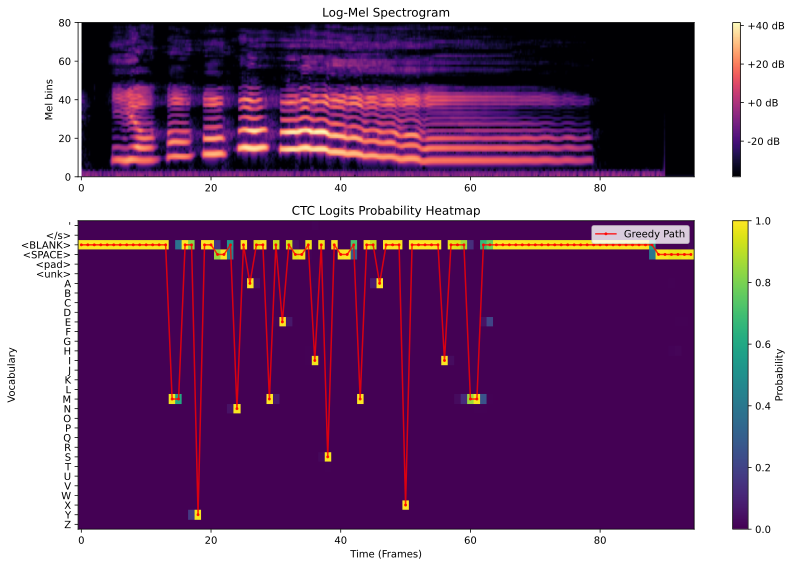

In [16]:
vocab_labels = list(processor.tokenizer.get_vocab().keys())

vocab_labels[processor.tokenizer.pad_token_id] = "<BLANK>"
vocab_labels[processor.tokenizer.word_delimiter_token_id] = "<SPACE>"

reordered_probs = probs[np.argsort(vocab_labels)[::-1]]

fig, (ax_spec, ax) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 2]})

im_spec = ax_spec.imshow(
    log_mel_spectrogram.numpy(), aspect='auto', origin='lower', cmap='magma',
    extent=[0, reordered_probs.shape[1], 0, log_mel_spectrogram.shape[0]]
)
ax_spec.set_title("Log-Mel Spectrogram")
ax_spec.set_ylabel("Mel bins")
plt.colorbar(im_spec, ax=ax_spec, format="%+2.0f dB")

im = ax.imshow(reordered_probs, aspect='auto', origin='lower', cmap='viridis', vmin=0.0, vmax=1.0)

greedy_path = np.argmax(reordered_probs, axis=0)

time_frames = range(reordered_probs.shape[1]) # Ось X
ax.plot(time_frames, greedy_path, color='red', marker='.', markersize=4, 
        linestyle='-', linewidth=1.5, alpha=0.8, label='Greedy Path')

ax.set_yticks(range(len(vocab_labels)))
ax.set_yticklabels(sorted(vocab_labels, reverse=True))
ax.set_xlabel("Time (Frames)")
ax.set_ylabel("Vocabulary")
ax.set_title("CTC Logits Probability Heatmap")

ax_spec.set_xlim(ax.get_xlim())

plt.colorbar(im, ax=ax, label="Probability")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## `3.3. Late Emission`

![](https://www.researchgate.net/publication/395339595/figure/fig4/AS:11431281625413103@1757302841119/Caption-adapted-from-the-CTC-paperGraves-et-al-2006-Framewise-and-CTC-networks.ppm)

Известно, что модели, обученные с CTC лоссом склонны выдавать пик вероятности символа в самый последний момент, когда буква уже почти закончилась. То есть модель ожидает максимального контекста перед тем, как сгенерировать очередной символ. Это достигается излишней генерацией $\varepsilon$ токенов. 

Добавление регуляризации на пути $A \in \mathcal{A}$ содержащие большое количество $\varepsilon$ позволяет улучшить качество forced alignment разметки на выходе модели: [Less Peaky and More Accurate CTC Forced Alignment by Label Priors](https://arxiv.org/pdf/2406.02560v2).

## `3.4. Decoding`

После того как звук прошел через Encoder, на выходе получается матрицу вероятностей, а не готовый текст. Процесс превращения этих вероятностей в финальный текст называется **декодированием**.

### `Жадное декодирование`

Самый простой и быстрый способ получить текст — на каждом шаге выбирать токен с максимальной вероятностью, игнорируя все остальные варианты:

1. На каждом фрейме $t$ берем $\arg\max$ по словарю: $$a^{\star}_t = \arg\max\limits_{a \in \hat{V}} p_t(a | X)$$
2. Получаем сырую строку (например, $h - h - e - e - l - l - \varepsilon - l - o - \  - w - o - r - l - d - \varepsilon$).
3. Применяем функцию схлопывания $B(\cdot) \to$ `hello world`.

В итоге получаем:

$$ Y_{\text{greedy}} = B(\arg\max_{A \in \mathcal{A}} P(A | X)) $$

<b style='color:red;'>В чем главная проблема Жадного декодирования?</b>

<details><summary>Ответ:</summary>>> 
Формально, CTC Loss оптимизирует $P(Y|X)$ в то время как Жадное декодирование оптимизирует $P(A|X)$, что математически некорректно. Такоей метод выбирает "лучший путь", но не "лучшую последовательность". Из-за этого он часто ошибается на неуверенных участках звука.

Простейший пример, когда Жадное декодирование ошибается:

| $a \in \hat{V}$ | $p_{1}(a)$ | $p_{2}(a)$ |
| :---: | :---: | :---: |
| a | 0.3 | 0.3 |
| b | 0.1 | 0.2 |
| $\varepsilon$ | 0.6 | 0.5 |

$$ Y_{\text{greedy}} = B(\varepsilon - \varepsilon) = \text{""}$$

$$
P(\text{"a"} | X) = P(a - \varepsilon | X) + P(\varepsilon - a | X) = 0.3 \cdot 0.5 + 0.6 \cdot 0.3 = 0.33 \ge P(\text{""} | X) = 0.6 \cdot 0.5 = 0.3
$$

</details>

### `Prefix Beam Search`

Чтобы найти истинно лучшую последовательность, нужно просуммировать вероятности всех путей, схлопывающихся в одну гипотезу. Beam Search делает это приближенно, храня $K$ лучших гипотез на каждом шаге.

$$
Y_{beam} \approx \arg\max_{Y} \sum_{A \in B^{-1}(Y)} P(A | X)
$$

В отличие от задач NLP, где каждый токен уникален, в CTC разные пути дают одинаковый текст.
* Путь 1: $\varepsilon - z - z-\varepsilon $
* Путь 2: $z-\varepsilon -\varepsilon - \varepsilon$
* Оба дают текст `z`.

Нам нужно **объединять** вероятности путей, ведущих к одной **текстовой гипотезе**, а не хранить их отдельно.

1.  Инициализируем Beam пустой гипотезой.
2.  Для каждого шага $t$:
    *   Берем все гипотезы из луча предыдущего шага.
    *   Пробуем дописать к ним каждый возможный токен из $\hat{V}$.
    *   Обновляем вероятности текстовых префиксов.
    *   Оставляем только топ-$K$ гипотез.

В CTC Beam Search мы обязаны **суммировать вероятности путей**, которые приводят к одному и тому же префиксу. 

Алгоритм поддерживает два состояния для каждого префикса: вероятность того, что префикс заканчивается на $\varepsilon$, и вероятность того, что он заканчивается на букву $a \in V$. Если новые пути генерируют одинаковый префикс, их вероятности складываются.

Этот метод гораздо точнее Greedy, но работает медленнее $O(M^{\prime} \cdot K \cdot |\hat{V}|)$ в отличие от $O(M^{\prime} \cdot |\hat{V}|)$ для Жадного декодирования.

<img src="./CTC-BeamSearch.svg" width="1000"/>

### `Внешняя Языковая Модель`

CTC акустические модели отлично распознают фонетику, но из-за свойства Contextual Independence плохо знают грамматику и контекст: модель может спутать `кот` и `код`, если звучат они похоже, так как модель не имеет никакой информации о языке. Для решения этой проблемы в процесс декодирования можно добавить внешнюю априорную информацию о языке через LM.

Самый популярный подход — **Beam Search Shallow Fusion**. На каждом шаге декодирования вероятности гипотезы модифицируется в соответствии с лингвистической информацией:

$$ \text{Score}(Y | X) = \log P(Y | X) + \lambda \log P_{\text{LM}}(Y) + \beta |Y| $$

* $P(Y | X)$ — вероятность от акустической модели.
* $P_{\text{LM}}(Y)$ — вероятность от языковой модели.
* $\lambda$ — вес языковой модели, который балансирует влияние акустики и языка. Если $\lambda$ велика, модель будет игнорировать звук и галлюцинировать текст. Если мала — ошибки акустики не будут исправлены.
* $\beta |Y|$ — **Length Penalty**. Без бонуса за длину, модель будет предпочитать короткие предложения, так как более длинные строки всегда имеют меньший скор.

Интегрировать нейронную сеть внутрь Beam Search не эффективно, так как необходимо вычислять вероятности гипотез $\mathcal{K}$ раз на один шаг декодинга. Поэтому для **First-pass decoding** используются простые **N-gram Языковые Модели**. Их главное преимущество — предсказание вероятности следующего слова выполняется за $\mathcal{O}(1)$ через поиск в хэш-таблице.

Пусть у нас есть последовательность токенов $W = (w_1, w_2, \dots, w_N)$. По Chain Rule, истинная вероятность этой последовательности равна:

$$P(w_1, w_2, \dots, w_N) = \prod_{i=1}^{N} P(w_i \mid w_1, \dots, w_{i-1})$$

Оценить вероятность слова при условии *всей* предыдущей истории невозможно (например, фраза `введение в машинное обучение с помощью sklearn` могла ни разу целиком не встретиться в обучающем корпусе текстов).

Предположим что выполняется **Марковское свойство: вероятность следующего слова зависит только от $N-1$ предыдущих слов**:
* **Unigram:** $P(w_i) \Longrightarrow P(W) \approx \prod\limits_{i=1}^{N} P(w_i)$ — слова независимы и учитывается только их частота.
* **Bigram:** $P(w_i \mid w_{i-1}) \Longrightarrow P(W) \approx \prod\limits_{i=1}^{N} P(w_i \mid w_{i-1})$ — вероятность зависит от одного предыдущего слова.
* **Trigram:** $P(w_i \mid w_{i-2}, w_{i-1})  \Longrightarrow P(W) \approx \prod\limits_{i=1}^{N} P(w_i \mid w_{i-1}, w_{i-2})$ — зависит от двух предыдущих.


Вероятности берутся напрямую из статистики текстовых корпусов методом максимального правдоподобия через отношение частот. Например, для Bigram:

$$
P(w_i \mid w_{i-1}) = \frac{\text{count}(w_{i-1}, w_i)}{\text{count}(w_{i-1})}
$$

<b style='color:red;'>Какая проблема может возникнуть при оценке вероятностей N-gram?</b>

<details><summary>Ответ:</summary>>> 
    
Если пара слов ни разу не встретилась в обучающем корпусе, то $\log(P(w_{i} \mid w_{i-1})) = -\infty$. 

Самый простой вариант избежать $-\infty$ — *Laplace smoothing*:

$$
P(w_i \mid w_{i-1}) \approx \frac{\text{count}(w_{i-1}, w_i) + \delta}{\text{count}(w_{i-1}) + \delta |V|}
$$
    
</details>

Пример улучшений от использования LM (3-layer LSTM) [Conformer: Convolution-augmented Transformer for Speech Recognition](https://arxiv.org/pdf/2005.08100):

| Method | #Params (M) | WER Without LM: testclean | WER Without LM: testother | WER With LM: testclean | WER With LM: testother |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Hybrid** | | | | | |
| Transformer  | - | - | - | $$2.26$$ | $$4.85$$ |
| **CTC** | | | | | |
| QuartzNet | $$19$$ | $$3.90$$ | $$11.28$$ | $$2.69$$ | $$7.25$$ |
| **LAS** | | | | | |
| Transformer  | $$270$$ | $$2.89$$ | $$6.98$$ | $$2.33$$ | $$5.17$$ |
| Transformer  | - | $$2.2$$ | $$5.6$$ | $$2.6$$ | $$5.7$$ |
| LSTM | $$360$$ | $$2.6$$ | $$6.0$$ | $$2.2$$ | $$5.2$$ |
| **Transducer** | | | | | |
| Transformer | $$139$$ | $$2.4$$ | $$5.6$$ | $$2.0$$ | $$4.6$$ |
| ContextNet(S)  | $$10.8$$ | $$2.9$$ | $$7.0$$ | $$2.3$$ | $$5.5$$ |
| ContextNet(M)  | $$31.4$$ | $$2.4$$ | $$5.4$$ | $$\bf 2.0$$ | $$4.5$$ |
| ContextNet(L)  | $$112.7$$ | $$\bf2.1$$ | $$4.6$$ | $$\bf 1.9$$ | $$4.1$$ |
| **Conformer** | | | | | |
| Conformer(S) | $$10.3$$ | $$\bf 2.7$$ | $$\bf 6.3$$ | $$\bf 2.1$$ | $$\bf 5.0$$ |
| Conformer(M) | $$30.7$$ | $$\bf 2.3$$ | $$\bf 5.0$$ | $$\bf 2.0$$ | $$\bf 4.3$$ |
| Conformer(L) | $$118.8$$ | $$\bf 2.1$$ | $$\bf 4.3$$ | $$\bf 1.9$$ | $$\bf 3.9$$ |

In [17]:
from torchaudio.models.decoder import ctc_decoder, download_pretrained_files

files = download_pretrained_files("librispeech-4-gram")

vocab_dict = processor.tokenizer.get_vocab()
tokens = [k.lower() for k, v in sorted(vocab_dict.items(), key=lambda x: x[1])]

decoder = ctc_decoder(
    lexicon=files.lexicon,
    tokens=tokens,
    lm=files.lm,
    nbest=3,
    beam_size=50,
    lm_weight=2.0,      # Насколько сильно мы доверяем Языковой Модели
    word_score=-1.0,    # Штраф за добавление нового слова (аналог Length Penalty)
    blank_token="<pad>",
    sil_token="|"
)

emissions = log_probs.transpose(0, 1).cpu()
beam_results = decoder(emissions)
best_hyp = beam_results[0][0]

lm_decoded_text = " ".join(best_hyp.words).upper()

print(f"Target Text:            '{text_target}'")
print(f"Greedy Decoding Result: '{decoded_text}'")
print(f"Beam Search + LM Result: '{lm_decoded_text}'")

[" ".join(_.words).upper() for _ in beam_results[0]]

Target Text:            'MY NAME IS MAXIM'
Greedy Decoding Result: 'MY NAME IS MAXIM'
Beam Search + LM Result: 'MY NAME IS MAXIM'


['MY NAME IS MAXIM', 'MY NAME IS MAXIME', 'MY NAME IS MAXIMS']

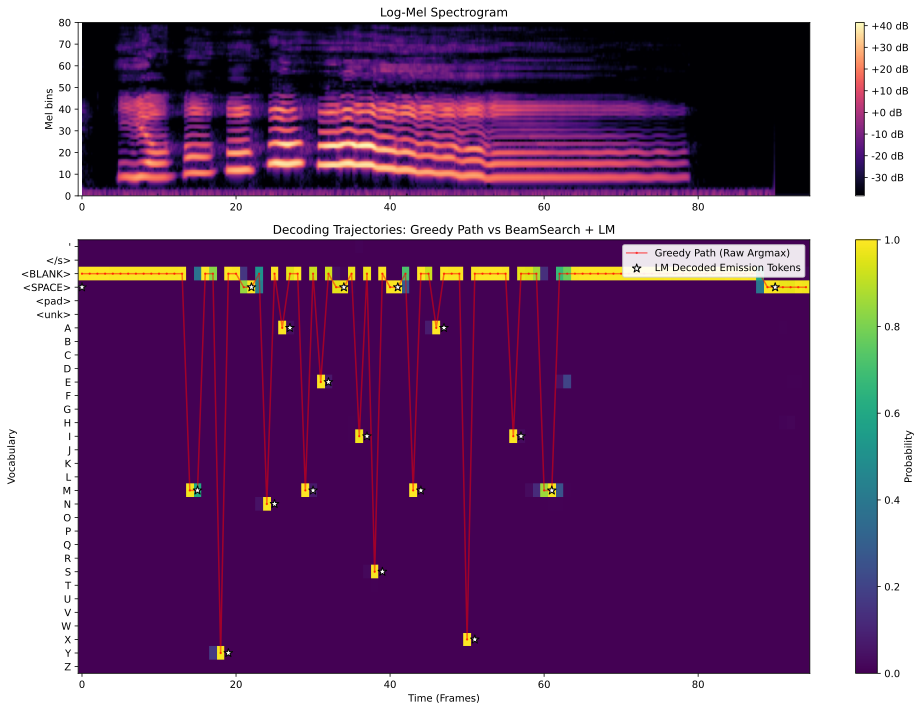

In [18]:
sort_idx = np.argsort(vocab_labels)[::-1]
id_to_y = {original_id: new_y for new_y, original_id in enumerate(sort_idx)}

fig, (ax_spec, ax) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), gridspec_kw={'height_ratios':[1, 2.5]})

im_spec = ax_spec.imshow(
    log_mel_spectrogram.numpy(), aspect='auto', origin='lower', cmap='magma',
    extent=[0, reordered_probs.shape[1], 0, log_mel_spectrogram.shape[0]]
)
ax_spec.set_title("Log-Mel Spectrogram")
ax_spec.set_ylabel("Mel bins")
plt.colorbar(im_spec, ax=ax_spec, format="%+2.0f dB")

im = ax.imshow(reordered_probs, aspect='auto', origin='lower', cmap='viridis', vmin=0.0, vmax=1.0)

time_frames = np.arange(reordered_probs.shape[1])
greedy_path_ids = probs.argmax(axis=0)  # Оригинальные ID токенов
greedy_y = [id_to_y[tid] for tid in greedy_path_ids]

ax.plot(time_frames, greedy_y, color='red', marker='.', markersize=3, 
        linestyle='-', linewidth=1.5, alpha=0.5, label='Greedy Path (Raw Argmax)')

lm_timesteps = best_hyp.timesteps.tolist()
lm_token_ids = best_hyp.tokens.tolist()

lm_y = [id_to_y[tid] for tid in lm_token_ids]

ax.scatter(lm_timesteps, lm_y, color='white', edgecolor='black', s=80, marker='*',
           zorder=5, label='LM Decoded Emission Tokens')

ax.set_yticks(range(len(vocab_labels)))
ax.set_yticklabels([vocab_labels[i] for i in sort_idx])
ax.set_xlabel("Time (Frames)")
ax.set_ylabel("Vocabulary")
ax.set_title("Decoding Trajectories: Greedy Path vs BeamSearch + LM")

ax_spec.set_xlim(ax.get_xlim())

plt.colorbar(im, ax=ax, label="Probability")
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

### `Rescoring`

Чтобы воспользоваться преимуществами больших языковых моделей на практике используют **Multi-pass decoding**:

**Генерация:**
Используется быстрая и простая N-gram LM (например, 3-gram). Из Beam Search достается не одна лучшая гипотеза, а **N-best list** (например, топ-10 лучших вариантов).

**Rescoring:**
LLM заново пересчитывает $P_{\text{LM}}(Y)$ только для этих $10$ вариантов. 

| Гипотеза из N-best list | Beam Score | LLM Score | Итог |
| :--- | :--- | :--- | :--- |
| найди последнюю серию молодого папа | -10.0 | -14.0 | -24.0 |
| **найди последнюю серию молодого папы** | -11.0 | **-10.0** | **-21.0** |
| найди последнюю серию молодово папа | -12.0 | -19.0 | -31.0 |

<b style='color:red;'>Как оценить, можно ли улучшить текущую акустическую модель с помощью LM?</b>

<details><summary>Ответ:</summary>>> 

Можно оценить верхнюю границу качества ASR пайплайна в зависимости от разных LM:

$$
\text{OracleWER}(\text{Hypotheses}, \text{Reference}) = \min\limits_{H \in \text{Hypotheses}} WER(H, \text{Reference})
$$
    
**Oracle WER** — это теоретически лучший WER, который можно получить, если всегда выбирать оптимальную гипотезу из сгенерированного N-best списка. Большая разница между Oracle WER и качеством текущего пайплайна говорит о том, что Rescoring LM недостаточно качественна.
</details>

Пример влияния Rescoring на ASR pipeline [Effect and Analysis of Large-scale Language Model Rescoring on Competitive ASR Systems](https://arxiv.org/pdf/2204.00212):

| Model | Baseline (Conformer-T) | BERT-base (uncased) | +scratch | +finetune | +context | +finetune +context | RoBERTa-base | +scratch | +finetune | +context | +finetune +context | BERT-large (uncased) | +scratch | +finetune | +context | +finetune +context | RoBERTa-large | +scratch | +finetune | +context | +finetune +context | Oracle (16-best) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Best $\lambda$** | $-$ | $0.05$ | $0.15$ | $0.15$ | $0.10$ | $0.20$ | $0.10$ | $0.15$ | $0.20$ | $0.15$ | $0.20$ | $0.05$ | $0.15$ | $0.25$ | $0.10$ | $0.15$ | $0.10$ | $0.10$ | $0.25$ | $0.10$ | $0.15$ | $-$ |
| **SWB** | $5.3$ | $5.3$ | $5.2$ | $\bf 5.0$ | $5.2$ | $\bf 5.0$ | $5.2$ | $5.3$ | $\bf 5.1$ | $5.2$ | $\bf 5.1$ | $5.2$ | $5.2$ | $\bf 5.1$ | $5.2$ | $\bf 5.1$ | $5.1$ | $5.2$ | $5.2$ | $5.1$ | $\bf 5.0$ | $2.6$ |
| **CH** | $8.9$ | $8.8$ | $8.7$ | $\bf 8.5$ | $8.6$ | $\bf 8.5$ | $8.7$ | $8.6$ | $8.6$ | $8.6$ | $\bf 8.5$ | $8.8$ | $8.7$ | $8.5$ | $8.6$ | $\bf 8.4$ | $8.6$ | $8.6$ | $\bf 8.5$ | $\bf 8.5$ | $\bf 8.5$ | $4.5$ |